<h1 style="text-align: center;">Notebook for CNN alone</h1>
<p style="text-align: center;">We feed a fully connected network with PCA modes</p>


In [1]:
import numpy as np
import torch
import modred as mr
import os
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import cm
import imageio
import os
from natsort import natsorted

import POD
import importlib
importlib.reload(POD)

import utils
importlib.reload(utils)

import data_analysis
importlib.reload(data_analysis)

import autoencoder_analysis
importlib.reload(autoencoder_analysis)

import cnn
importlib.reload(cnn)

%matplotlib inline
matplotlib.pyplot.rc('text', usetex=True)

fontsize = 18

In [2]:
from utils import get_freer_gpu

device = get_freer_gpu() if torch.cuda.is_available() else "cpu"

Selected GPU 1 with 7669 MB free memory 


In [3]:
from data_analysis import Simulation
current_directory = '../'

simulation = Simulation(current_directory, Lambda = 0.01)
time, x, z, u, w, T, umean, wmean, Tmean = simulation.import_data()
X = np.swapaxes(simulation.X, 0, 1)
simulation.image_rgb()
h = simulation.h
l = simulation.l

data from ..//data/bulk_L0.01.npz


# Results from CNN

batch_size: 128
size1: (50, 30)
size2: (30, 20)
size3: (20, 15)
size4: (15, 10)
size5: (8, 5)
min_30_epoch: None
num_epoch: 100
lr: 0.0001
weight_decay: 0
execution_time_in_min: 4.1377063393592834
epoch_1: {'loss': 0.051528070122003555, 'nmse': 9.616696453094482, 'time': 0.07992194890975952}
epoch_2: {'loss': 0.036031320691108704, 'nmse': 5.858034229278564, 'time': 0.11841373840967814}
epoch_3: {'loss': 0.030862653627991676, 'nmse': 9.76283655166626, 'time': 0.15677969058354696}
epoch_4: {'loss': 0.025786342099308968, 'nmse': 8.165318965911865, 'time': 0.19568316141764322}
epoch_5: {'loss': 0.021577924489974976, 'nmse': 5.6419600486755375, 'time': 0.23699736992518108}
epoch_6: {'loss': 0.01811048947274685, 'nmse': 8.188044309616089, 'time': 0.27838266690572105}
epoch_7: {'loss': 0.01606035977602005, 'nmse': 5.505156946182251, 'time': 0.32015885909398395}
epoch_8: {'loss': 0.015916865319013596, 'nmse': 5.484943580627442, 'time': 0.36158748865127566}
epoch_9: {'loss': 0.01483645662665367

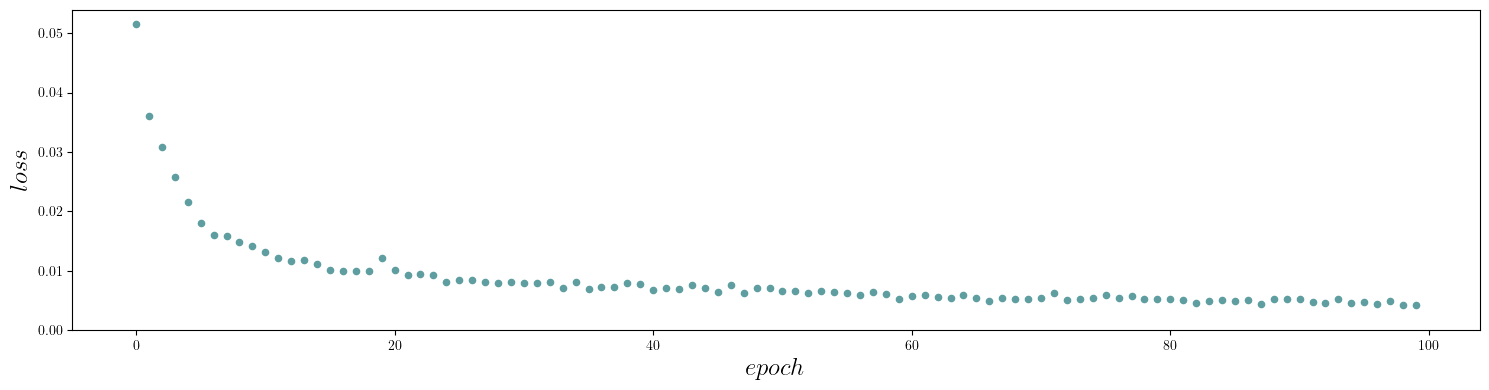

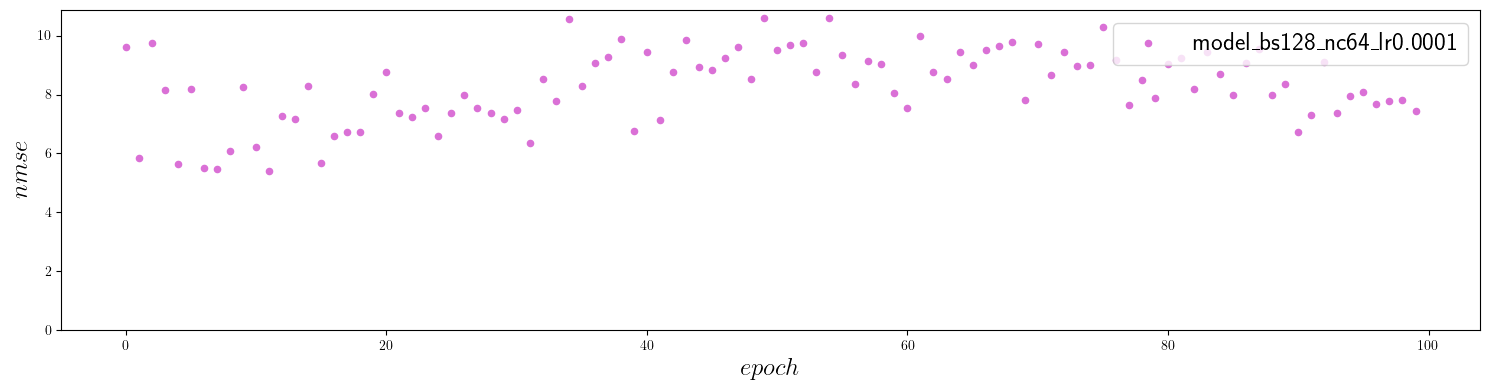

In [18]:
batch_size = 128
lr = 1e-4
nc = 64
directory = f'{current_directory}/results/autoencoder/cnn_alone/changesizes/'
title = f'model_bs{batch_size}_nc{nc}_lr{lr}'

from autoencoder_analysis import plot_info_training
sizes = plot_info_training(directory, title, return_sizes = True)

In [5]:
print(sizes)

[(50, 30), (30, 20), (20, 15), (15, 10), (8, 5)]


In [14]:
from cnn import CNN_sizes
def apply_cnn(n_channels, batch_size, encoded = False):
    autoencoder = CNN_sizes(device, sizes, n_channels)

    autoencoder.load_state_dict(torch.load(directory + f'model_bs{batch_size}_nc{n_channels}_lr{lr}.pt'))
    autoencoder.eval() 

    with torch.no_grad():
        encoded_data = autoencoder.encoder(x.to(device))

    with torch.no_grad():
        decoded_data = autoencoder.decoder(encoded_data)

    if encoded : 
        return decoded_data, encoded_data
    return decoded_data


decoded_data, encoded_data = apply_cnn(nc, batch_size, encoded = True)

AttributeError: 'numpy.ndarray' object has no attribute 'to'

In [27]:
x.dtype

dtype('float64')

In [6]:
def compute_nmse_cnn(test_loader, bs, nc = 64, lr = 1e-4, encoded = False, directory = f'{current_directory}/results/autoencoder/cnn_alone/'):
    from cnn import CNN_sizes
    from utils import compute_nmse
    from utils import get_variables_from_info_text
    
    title = f'model_bs{bs}_nc{nc}_lr{lr}'

    variables, sizes = get_variables_from_info_text(directory, title + '_info.txt', print = False)
    print(sizes)
    autoencoder = CNN_sizes(device = device, sizes = sizes)
    
    autoencoder.load_state_dict(torch.load(directory + title + '.pt'))
    autoencoder.eval()  

    
    with torch.no_grad():
        total_nmse = 0
        num_batches = 0

    for x, t in test_loader:
        x = x.to(torch.float32)
        encoded_data = autoencoder.encoder(x)

        decoded_data = autoencoder.decoder(encoded_data)
        
        nmse = compute_nmse(decoded_data, x)
        total_nmse += nmse
        num_batches += 1

    average_nmse = total_nmse / num_batches

    return average_nmse

In [7]:
from training import SimuDataset
from torch.utils.data import DataLoader

print(directory)
bs_values = [4, 10, 25, 50, 128]

t_test = int(0.9*simulation.m + 1)
batch_size = 4


test_set = SimuDataset(simulation, device,  rgb = True, mode = 'test', training_ratio = 0.9)
test_loader = DataLoader(dataset = test_set, batch_size = 4, shuffle = True)

whole_set = SimuDataset(simulation, device,  rgb = True, mode = 'whole', training_ratio = 0.9)
whole_loader = DataLoader(dataset = whole_set, batch_size = 4, shuffle = True)

train_set = SimuDataset(simulation, device,  rgb = True, mode = 'train', training_ratio = 0.9)
train_loader = DataLoader(dataset = train_set, batch_size = 4, shuffle = True)


nmse = []
nmse_test = []
nmse_train = []

for i, bs in enumerate(bs_values):
    print(bs)
    nmse.append(compute_nmse_cnn(whole_loader, bs = bs, directory = directory))
    nmse_test.append(compute_nmse_cnn(test_loader, bs = bs, directory = directory))
    nmse_train.append(compute_nmse_cnn(train_loader, bs = bs, directory = directory))
    
print(nmse, nmse_test, nmse_train)

..//results/autoencoder/cnn_alone/changesizes/
4
[(50, 30), (30, 20), (20, 15), (15, 10), (8, 5)]
[(50, 30), (30, 20), (20, 15), (15, 10), (8, 5)]
[(50, 30), (30, 20), (20, 15), (15, 10), (8, 5)]
10
[(50, 30), (30, 20), (20, 15), (15, 10), (8, 5)]
[(50, 30), (30, 20), (20, 15), (15, 10), (8, 5)]
[(50, 30), (30, 20), (20, 15), (15, 10), (8, 5)]
25
[(50, 30), (30, 20), (20, 15), (15, 10), (8, 5)]
[(50, 30), (30, 20), (20, 15), (15, 10), (8, 5)]
[(50, 30), (30, 20), (20, 15), (15, 10), (8, 5)]
50
[(50, 30), (30, 20), (20, 15), (15, 10), (8, 5)]
[(50, 30), (30, 20), (20, 15), (15, 10), (8, 5)]
[(50, 30), (30, 20), (20, 15), (15, 10), (8, 5)]
128
[(50, 30), (30, 20), (20, 15), (15, 10), (8, 5)]
[(50, 30), (30, 20), (20, 15), (15, 10), (8, 5)]
[(50, 30), (30, 20), (20, 15), (15, 10), (8, 5)]
[0.228788747470671, 0.555744510880473, 125.79157485288073, 2.686707325484687, 1.9854048227966403] [0.05309363817618151, 1.6964408391790025, 30.36274743967565, 1.265712557989321, 1.3105504769048872] [0.24

In [8]:
print(nmse, nmse_test, nmse_train)

[0.228788747470671, 0.555744510880473, 125.79157485288073, 2.686707325484687, 1.9854048227966403] [0.05309363817618151, 1.6964408391790025, 30.36274743967565, 1.265712557989321, 1.3105504769048872] [0.243543010476611, 0.4433903888366046, 132.90022539784587, 2.831379761598782, 2.0419867420052396]


In [13]:


def plot_NMSE(K_values, nmse, nmse_train, nmse_test, title = "FCNN", i = 0, j = len(bs_values), fontsize = 18, NMSE_pca = None, K_values_pca = None):
    fig, ax2 = plt.subplots(figsize = (10, 7)) 
    # ax2.scatter(K_values[i:j], nmse[i:j], s = 40, c = 'orchid', label = r"NMSE for the whole data")
    # ax2.plot(K_values[i:j], nmse[i:j], c = 'orchid', linestyle='-')
    ax2.scatter(K_values[i:j], nmse_train[i:j], s = 40, c = 'palegreen', label = r"NMSE for the trained set")
    ax2.plot(K_values[i:j], nmse_train[i:j], c = 'palegreen', linestyle='-')
    ax2.scatter(K_values[i:j], nmse_test[i:j], s = 40, c = 'salmon', label = r"NMSE for the test set")
    ax2.plot(K_values[i:j], nmse_test[i:j], c = 'salmon', linestyle='-')

    if NMSE_pca is not None:
        ax2.scatter(K_values[i:j], NMSE_pca[i:i + len(K_values[i:j])], s = 40, c = 'orchid', label = r"NMSE for PCA")
        ax2.plot(K_values[i:j], NMSE_pca[i:i + len(K_values[i:j])], c = 'orchid', linestyle='-')
    # ax.set_title(r"Residual norm")
    ax2.set_ylabel(r"NMSE", fontsize = fontsize)
    ax2.set_xlabel(r'K', fontsize = fontsize)
    ax2.set_ylim(bottom = 0)
    ax2.legend(fontsize = fontsize)
    ax2.set_ylim(bottom = 0)
    fig.suptitle(title, fontsize = fontsize)
    # fig.suptitle(f'number of modes = {num_modes} ', fontsize = fontsize)
    fig.tight_layout()

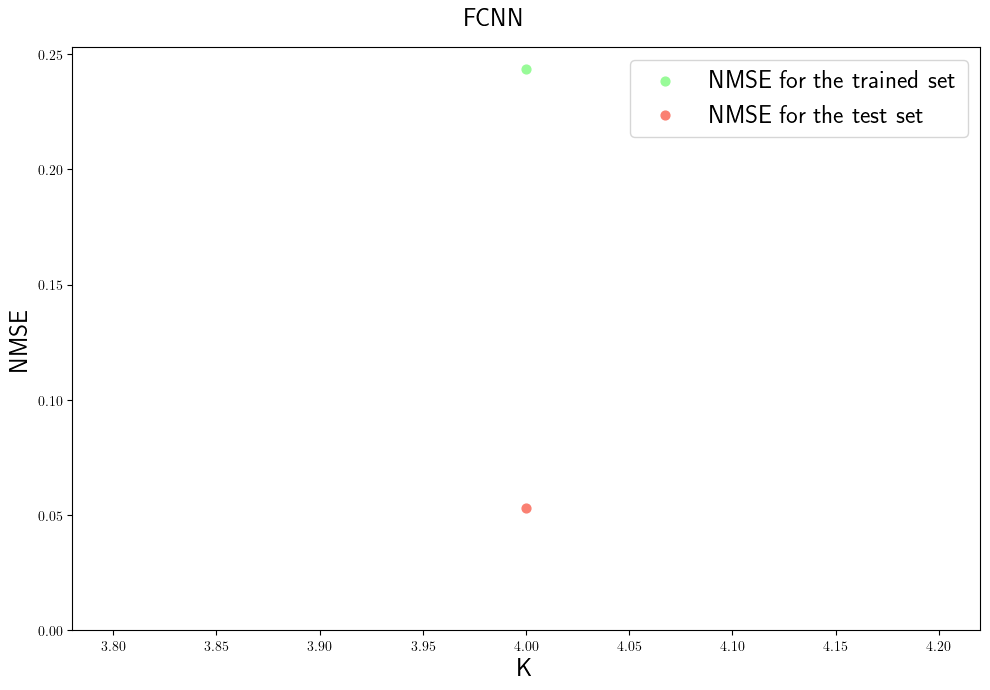

In [20]:
i = 0
j = 1
plot_NMSE(bs_values, nmse, nmse_train, nmse_test, title = "FCNN", i = i, j = j)